# Create a dataset for EVASPA with landsat8 data 
* On a specific S2 tile ID
* On S2 tiles corresponding to a specific ROI

### Imports

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
sys.path.append("../src")

In [5]:
import os
import geopandas as gpd
from tqdm import tqdm
from sensorsio import mgrs

In [6]:
from etdataset.ls8 import create_dataset
from etdataset.plot import plot_images
from etdataset.common import write_dataset

### Inputs 
* Landsat product path
* S2 tile id or ROI path

In [7]:
if not os.environ.get("DATA_PATH"):
    raise Exception("DATA_PATH not defined")

In [8]:
data_path = os.environ["DATA_PATH"]

In [9]:
ls8_path = os.path.join(data_path,"Landsat8/LC09_L2SP_205050_20230327_20230329_02_T1/")
s2_tile_id = "28PCA"
roi_path = os.path.join(data_path,"zones/Zone_Senegal_Centre.shp") 

In [10]:
ls8_path

'/home/sarrazine/data/Landsat8/LC09_L2SP_205050_20230327_20230329_02_T1/'

In [11]:
roi_path

'/home/sarrazine/data/zones/Zone_Senegal_Centre.shp'

### Create dataset from Landsat8 product for a specific S2 tile ID

In [12]:
ls8 = create_dataset(ls8_path, s2_tile_id)

/home/sarrazine/pyenvs/cesbio/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


(<Figure size 1500x1500 with 11 Axes>,
 array([[<Axes: title={'center': 'RGB'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'LST'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Emissivity'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Albedo'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'NDVI'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'LAI'}, xlabel='x', ylabel='y'>]],
       dtype=object))

/home/sarrazine/pyenvs/cesbio/lib/python3.10/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


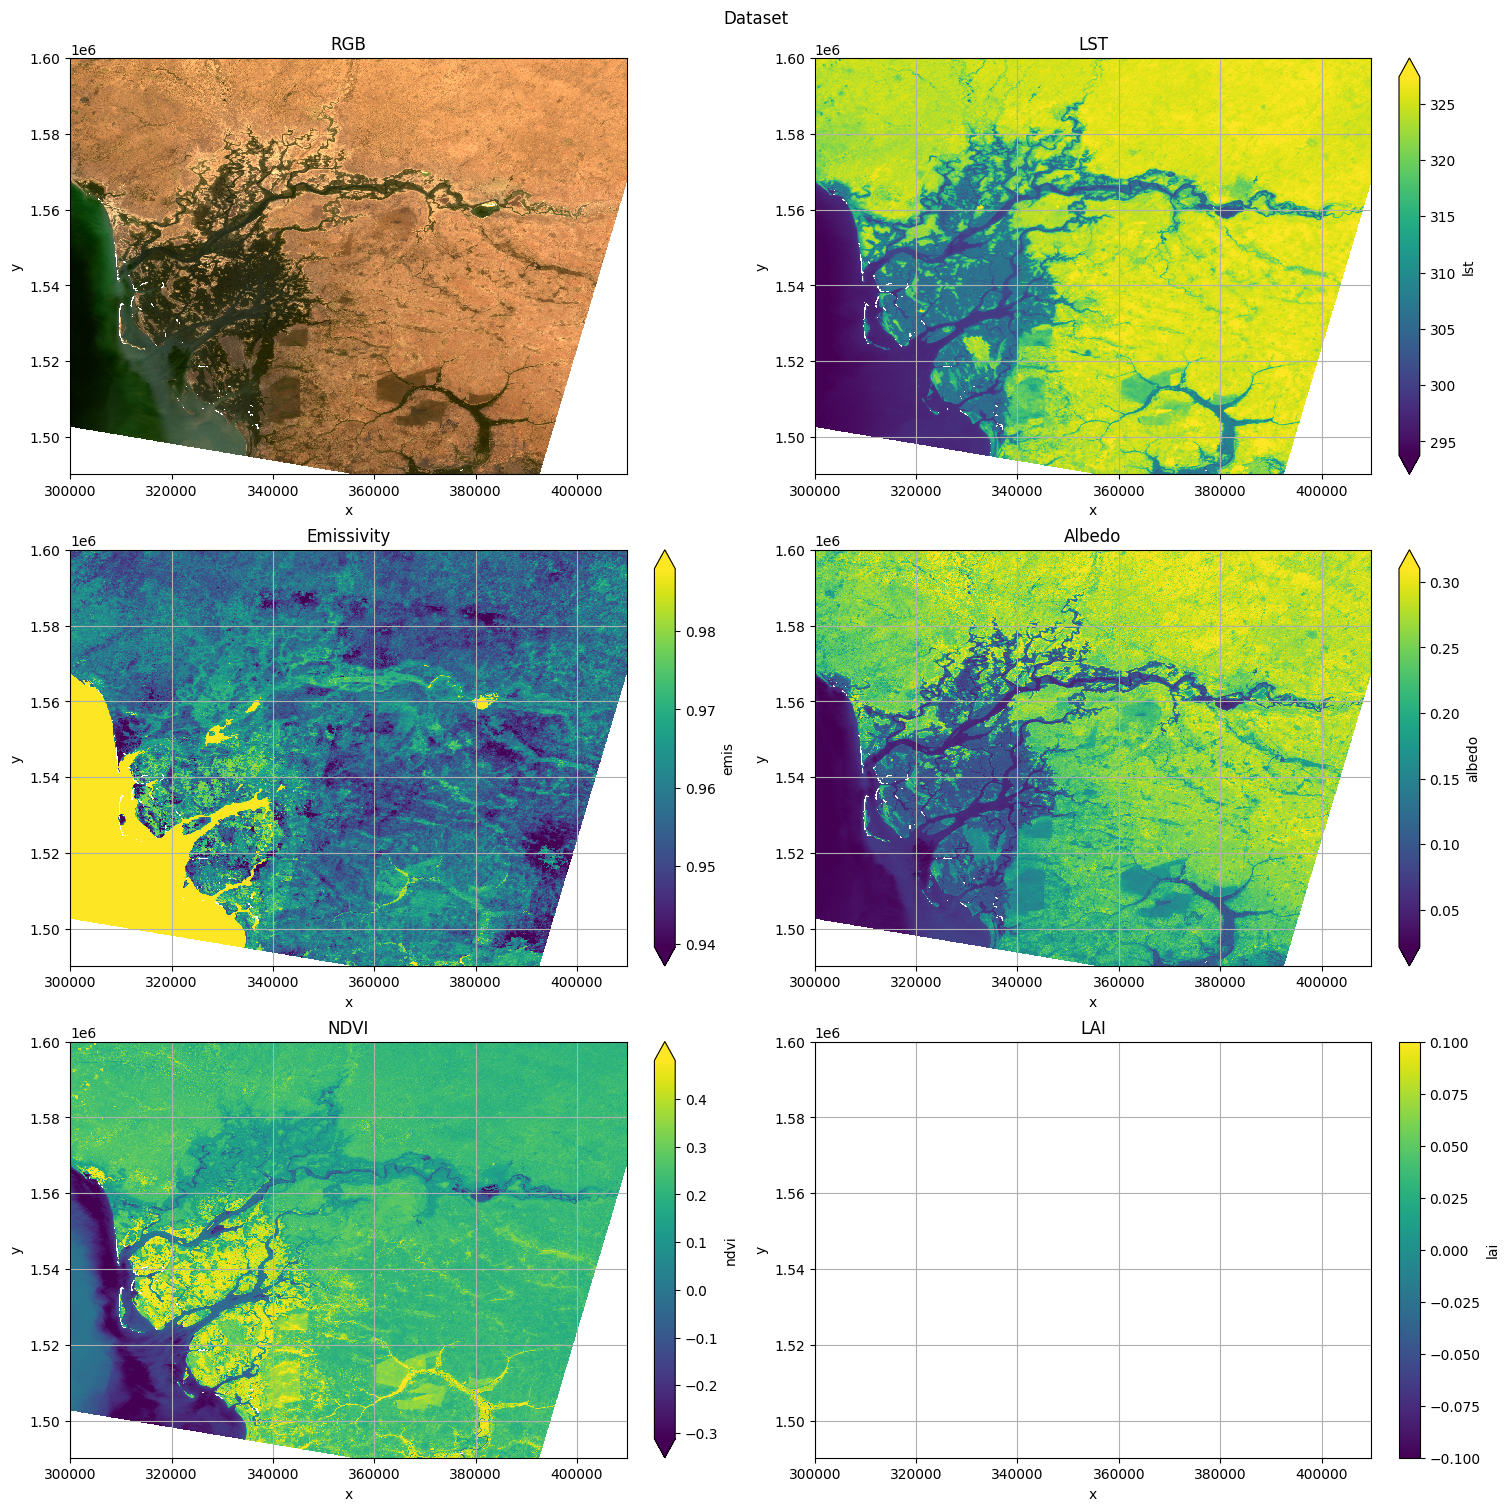

In [13]:
plot_images(ls8)

In [14]:
ls8.name

'Landsat'

In [17]:
ls8.date

datetime.datetime(2023, 3, 27, 0, 0)

### Create datasets from Landsat8 product for ROI

In [15]:
roi = gpd.read_file(roi_path)
roi_poly = roi.geometry[0]
crs_poly = roi.crs

In [16]:
tile_ids = mgrs.get_mgrs_tiles_from_roi(roi_poly,crs_poly)
tile_ids 

TypeError: Value after * must be an iterable, not Polygon

In [ ]:
datasets = []
for tile_id in tqdm(tile_ids):
    ls8 = create_dataset(ls8_path, tile_id)
    datasets.append(ls8)

In [ ]:
for ds in tqdm(datasets):
    write_dataset(ds)